# RYB Mixture Plate Analysis — V2 (Extended)
**Date:** 02-07-2026  
**Experiment:** 48 binary pairs (R+Y, R+B, Y+B) + 48 random mixtures (R,Y,B,W)  
**Goal:** Build forward model (volumes → absorbance) and inverse model (absorbance → volumes)

**V2 additions (§13–§17):** Feature engineering, regularization, classification, constrained inverse model

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
import os

folder_path = "02-07_RYB Mixture"
wavelengths = [450, 562, 600, 650]

## 1. Load Absorbance Data

In [2]:
# Load all 4 wavelength CSVs into a dict of DataFrames
abs_data = {}
for wl in wavelengths:
    fp = os.path.join(folder_path, f"RYB_Mixture_Plate{wl}nm.csv")
    df = pd.read_csv(fp, index_col=0)
    # Keep only rows A-H (plate data)
    df = df.loc[df.index.isin(['A','B','C','D','E','F','G','H'])]
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df[~df.index.duplicated(keep='first')]
    abs_data[wl] = df
    print(f"{wl}nm: shape {df.shape}, range [{df.min().min():.3f}, {df.max().max():.3f}] OD")

450nm: shape (8, 12), range [0.206, 1.865] OD
562nm: shape (8, 12), range [0.121, 1.031] OD
600nm: shape (8, 12), range [0.037, 1.631] OD
650nm: shape (8, 12), range [0.035, 1.817] OD


## 2. Heatmaps

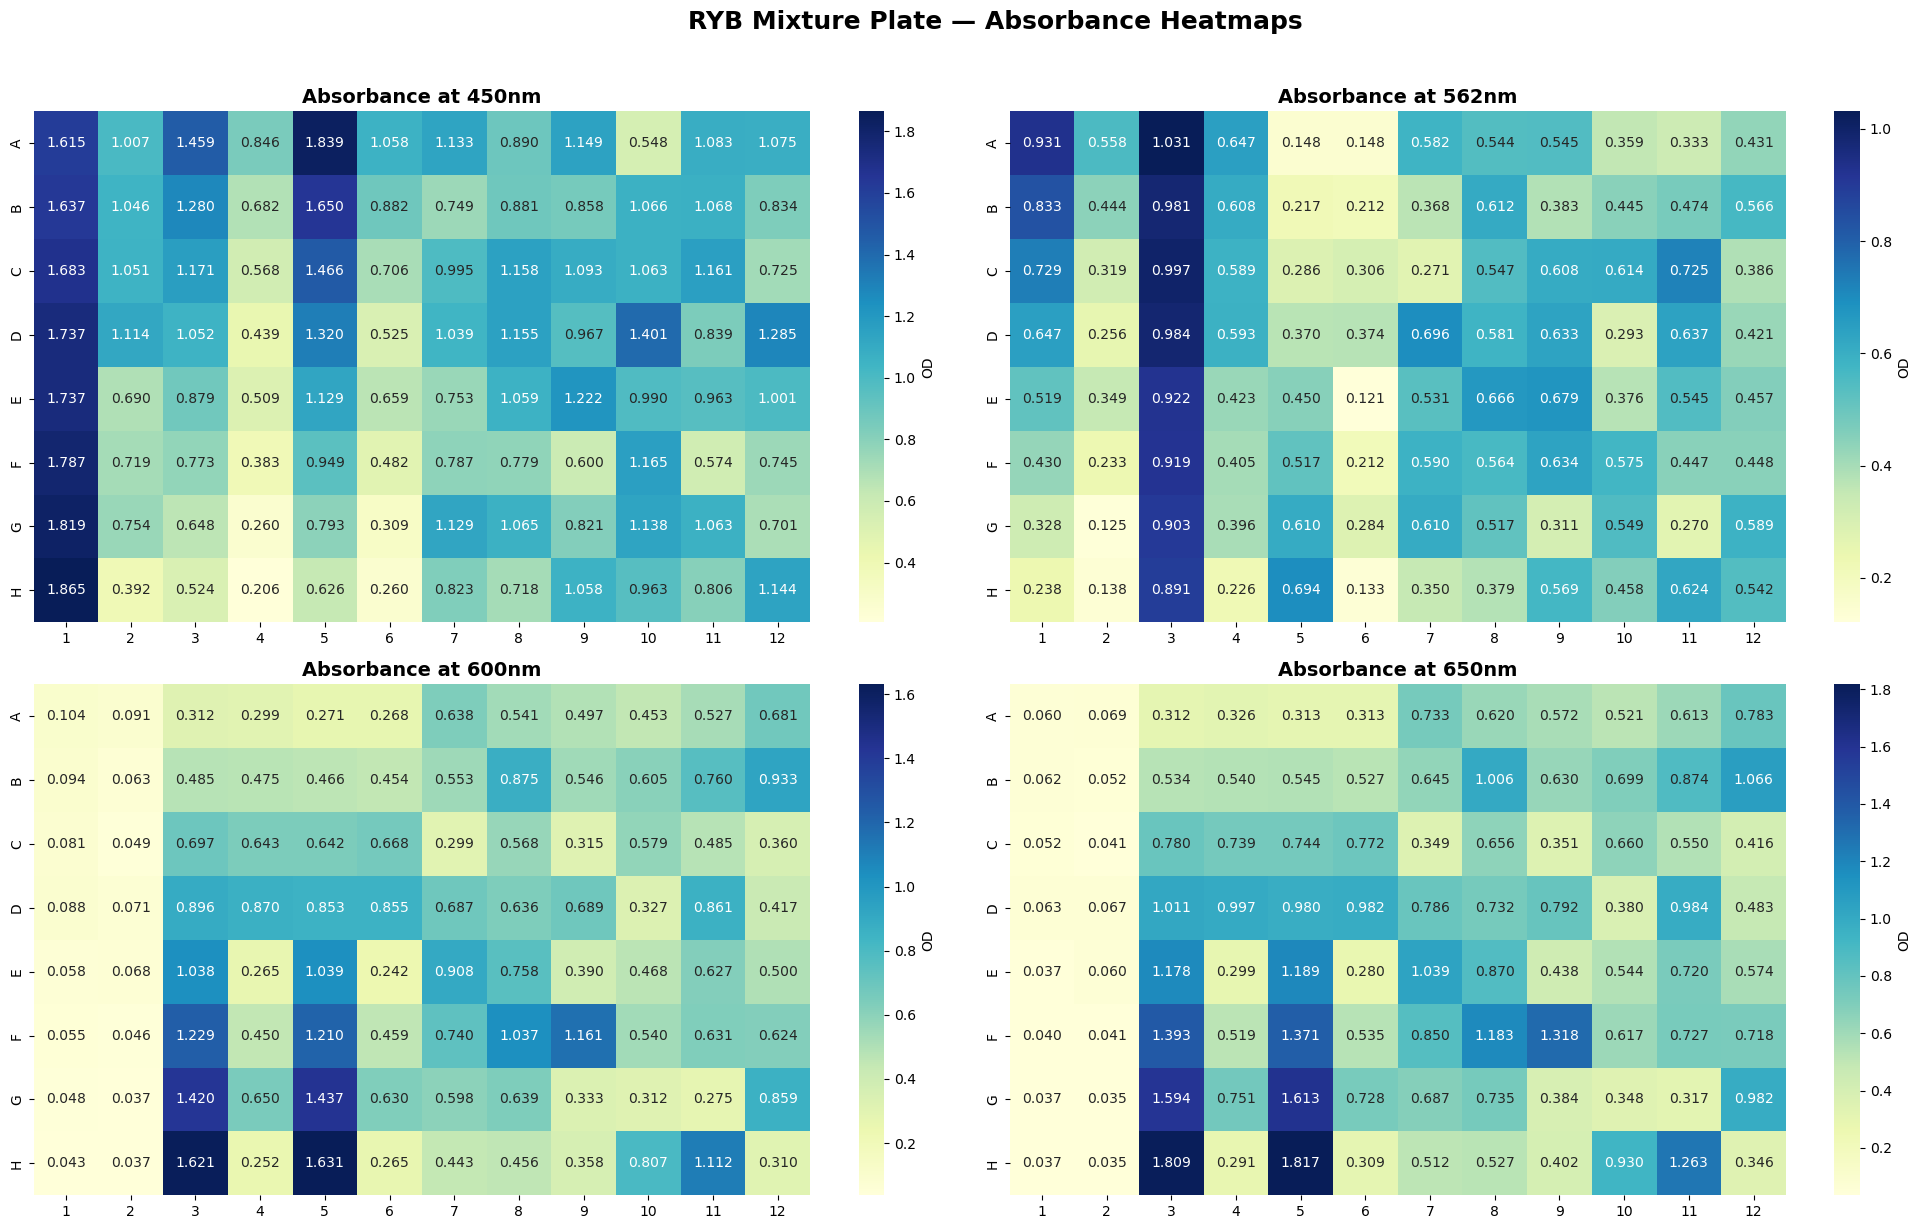

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
for ax, wl in zip(axes.flat, wavelengths):
    df = abs_data[wl]
    sns.heatmap(df, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax, cbar_kws={'label': 'OD'})
    ax.set_title(f"Absorbance at {wl}nm", fontsize=14, fontweight='bold')
plt.suptitle("RYB Mixture Plate — Absorbance Heatmaps", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "Heatmaps_All_Wavelengths.png"), dpi=300, bbox_inches='tight')
plt.show()

## 3. Build Volume Arrays (must match protocol exactly)
Reproduce the exact same volumes used in `mixture_protocol.py` with seed=42.

In [4]:
total_vol = 200
min_vol = 20

# ---- Binary Pairs (48 wells) ----
def make_binary_pair(idx_a, idx_b):
    wells = []
    for a, b in [(180,20),(160,40),(140,60),(120,80),
                  (100,100),(80,120),(60,140),(40,160)]:
        vol = [0, 0, 0, 0]
        vol[idx_a], vol[idx_b] = a, b
        wells.append(vol)
    for a, b in [(100,20),(80,40),(60,60),(40,80)]:
        vol = [0, 0, 0, 0]
        vol[idx_a], vol[idx_b] = a, b
        vol[3] = total_vol - a - b
        wells.append(vol)
    for a, b, w in [(60,20,120),(40,40,120),(20,60,120),(20,20,160)]:
        vol = [0, 0, 0, 0]
        vol[idx_a], vol[idx_b] = a, b
        vol[3] = w
        wells.append(vol)
    return wells

binary = make_binary_pair(0, 1) + make_binary_pair(0, 2) + make_binary_pair(1, 2)

# ---- Random Mixtures (48 wells, Dirichlet, seed=42) ----
rng = np.random.default_rng(seed=42)
random_wells = []
for _ in range(48):
    fracs = rng.dirichlet([1, 1, 1, 1])
    remaining = total_vol - 4 * min_vol
    vols = np.array([min_vol] * 4, dtype=float) + fracs * remaining
    vols = np.round(vols).astype(int)
    diff = total_vol - int(vols.sum())
    if diff != 0:
        vols[np.argmax(vols)] += diff
    random_wells.append(vols.tolist())

all_volumes = binary + random_wells

# Create volume DataFrame
vol_df = pd.DataFrame(all_volumes, columns=['R', 'Y', 'B', 'W'])
vol_df.index.name = 'well_idx'
print(f"Volume array: {vol_df.shape}")
print(f"All totals = 200: {(vol_df.sum(axis=1) == 200).all()}")
vol_df.describe()

Volume array: (96, 4)
All totals = 200: True


,R,Y,B,W
count,96.000000,96.000000,96.000000,96.000000
mean,51.875000,49.729167,48.625000,49.770833
std,41.917274,38.826871,36.915622,42.904172
min,0.000000,0.000000,0.000000,0.000000
25%,23.750000,23.000000,21.500000,16.500000
50%,41.000000,42.500000,43.500000,40.500000
75%,72.000000,64.250000,63.750000,80.000000
max,180.000000,180.000000,160.000000,160.000000


## 4. Combine Volumes + Absorbance into One Table

In [5]:
# Flatten absorbance data in COLUMN-FIRST order to match Opentrons wells()
# Opentrons wells() = A1, B1, C1, ..., H1, A2, B2, ..., H12
rows = ['A','B','C','D','E','F','G','H']
cols = [str(i) for i in range(1, 13)]

abs_flat = {}
for wl in wavelengths:
    vals = []
    for c in cols:        # column first!
        for r in rows:    # then rows within each column
            vals.append(abs_data[wl].loc[r, c])
    abs_flat[f'A{wl}'] = vals

abs_df = pd.DataFrame(abs_flat)

# Combine
data = pd.concat([vol_df.reset_index(drop=True), abs_df], axis=1)

# Add well labels (column-first order)
well_labels = [f"{r}{c}" for c in range(1, 13) for r in rows]
data.insert(0, 'Well', well_labels)

# Add pair type
pair_type = ['R+Y']*16 + ['R+B']*16 + ['Y+B']*16 + ['Random']*48
data.insert(1, 'Type', pair_type)

# Color map for pair types (used throughout the notebook)
colors_map = {'R+Y': 'tab:orange', 'R+B': 'tab:purple', 'Y+B': 'tab:green', 'Random': 'tab:gray'}

print(f"Combined dataset: {data.shape}")
print(f"\nSanity check — first few wells (should be column-first):")
data.head(10)

Combined dataset: (96, 10)

Sanity check — first few wells (should be column-first):


,Well,Type,R,Y,B,W,A450,A562,A600,A650
0,A1,R+Y,180,20,0,0,1.615,0.931,0.104,0.060
1,B1,R+Y,160,40,0,0,1.637,0.833,0.094,0.062
2,C1,R+Y,140,60,0,0,1.683,0.729,0.081,0.052
3,D1,R+Y,120,80,0,0,1.737,0.647,0.088,0.063
4,E1,R+Y,100,100,0,0,1.737,0.519,0.058,0.037
5,F1,R+Y,80,120,0,0,1.787,0.430,0.055,0.040
6,G1,R+Y,60,140,0,0,1.819,0.328,0.048,0.037
7,H1,R+Y,40,160,0,0,1.865,0.238,0.043,0.037
8,A2,R+Y,100,20,0,80,1.007,0.558,0.091,0.069
9,B2,R+Y,80,40,0,80,1.046,0.444,0.063,0.052


In [6]:
# Quick sanity check: show some statistics
print("=" * 50)
print("Absorbance Statistics")
print("=" * 50)
for wl in wavelengths:
    col = f'A{wl}'
    print(f"{wl}nm: min={data[col].min():.3f}, max={data[col].max():.3f}, mean={data[col].mean():.3f}")

# Check for saturation (OD > 3.0)
for wl in wavelengths:
    col = f'A{wl}'
    saturated = (data[col] > 3.0).sum()
    if saturated > 0:
        print(f"⚠️ {wl}nm: {saturated} wells above OD 3.0 (saturation!)")

Absorbance Statistics
450nm: min=0.206, max=1.865, mean=0.972
562nm: min=0.121, max=1.031, mean=0.500
600nm: min=0.037, max=1.631, mean=0.549
650nm: min=0.035, max=1.817, mean=0.623


### 4a. Full 96-Well Data Table
All 96 wells with volumes (µL) and absorbance (OD) — scroll to see the full table.

In [7]:
# Display all 96 wells (dark-theme compatible)
pd.set_option('display.max_rows', 100)

display_df = data.copy()
display_df.index = range(1, 97)  # 1-based index
display_df.index.name = '#'

# Style: dark-theme friendly — strong background + dark text forced
def highlight_type(row):
    color_map = {
        'R+Y': 'background-color: #e65100; color: #ffffff',   # deep orange + white text
        'R+B': 'background-color: #7b1fa2; color: #ffffff',   # deep purple + white text
        'Y+B': 'background-color: #2e7d32; color: #ffffff',   # deep green + white text
        'Random': 'background-color: #616161; color: #ffffff'  # dark gray + white text
    }
    return [color_map.get(row['Type'], '')] * len(row)

def highlight_zeros(val):
    if isinstance(val, (int, float)) and val == 0:
        return 'color: #999999'
    return ''

(display_df.style
    .apply(highlight_type, axis=1)
    .map(highlight_zeros, subset=['R', 'Y', 'B', 'W'])
    .format({'A450': '{:.3f}', 'A562': '{:.3f}', 'A600': '{:.3f}', 'A650': '{:.3f}'})
    .set_properties(**{
        'font-size': '12px',
        'border': '1px solid #555',
        'text-align': 'center',
        'padding': '4px 8px',
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#212121'),
            ('color', '#ffffff'),
            ('font-weight', 'bold'),
            ('font-size', '13px'),
            ('border', '1px solid #555'),
            ('text-align', 'center'),
        ]},
        {'selector': 'caption', 'props': [
            ('font-size', '16px'),
            ('font-weight', 'bold'),
            ('margin-bottom', '8px'),
            ('color', '#ffffff'),
        ]},
    ])
    .set_caption('96-Well Plate: Volumes (µL) and Absorbance (OD)')
)

,Well,Type,R,Y,B,W,A450,A562,A600,A650
#,,,,,,,,,,
1,A1,R+Y,180,20,0,0,1.615,0.931,0.104,0.060
2,B1,R+Y,160,40,0,0,1.637,0.833,0.094,0.062
3,C1,R+Y,140,60,0,0,1.683,0.729,0.081,0.052
4,D1,R+Y,120,80,0,0,1.737,0.647,0.088,0.063
5,E1,R+Y,100,100,0,0,1.737,0.519,0.058,0.037
6,F1,R+Y,80,120,0,0,1.787,0.430,0.055,0.040
7,G1,R+Y,60,140,0,0,1.819,0.328,0.048,0.037
8,H1,R+Y,40,160,0,0,1.865,0.238,0.043,0.037
9,A2,R+Y,100,20,0,80,1.007,0.558,0.091,0.069


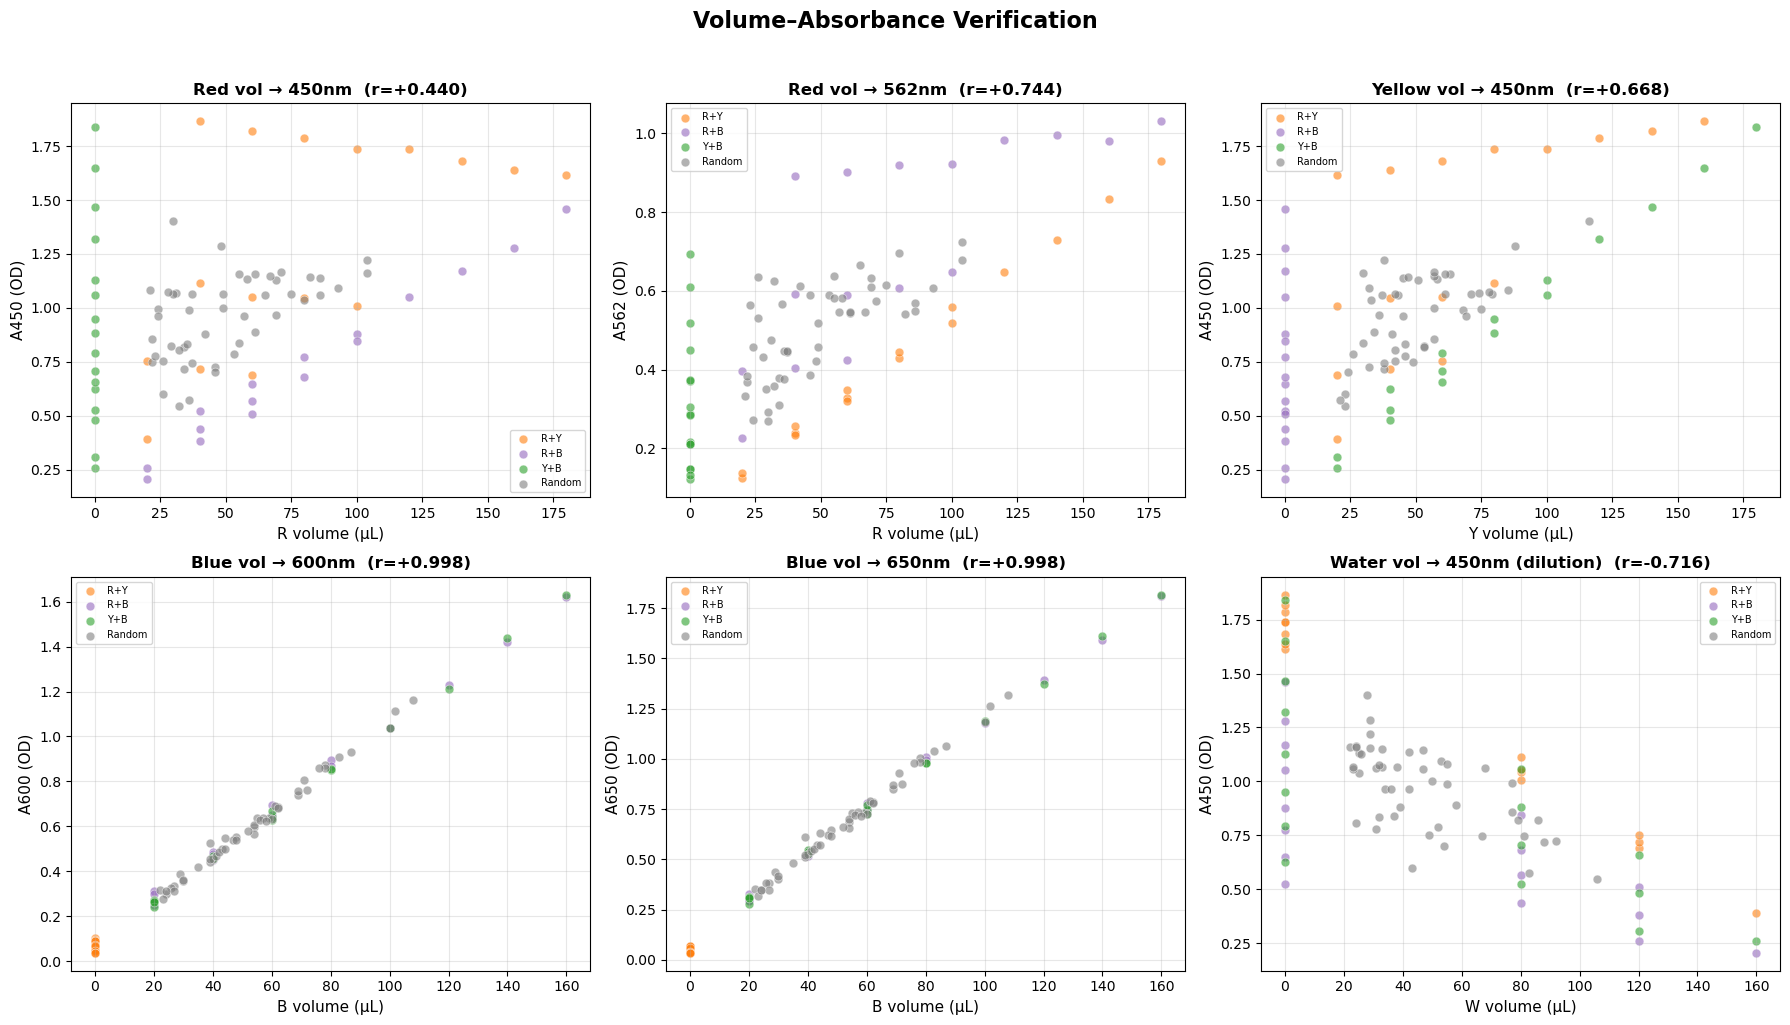

In [8]:
# Visual verification: Volume vs Absorbance scatter for each dye
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

vol_abs_pairs = [
    ('R', 'A450', 'Red vol → 450nm'),
    ('R', 'A562', 'Red vol → 562nm'),
    ('Y', 'A450', 'Yellow vol → 450nm'),
    ('B', 'A600', 'Blue vol → 600nm'),
    ('B', 'A650', 'Blue vol → 650nm'),
    ('W', 'A450', 'Water vol → 450nm (dilution)'),
]

for ax, (vcol, acol, title) in zip(axes.flat, vol_abs_pairs):
    for ptype, color in colors_map.items():
        mask = data['Type'] == ptype
        ax.scatter(data.loc[mask, vcol], data.loc[mask, acol], 
                   c=color, label=ptype, alpha=0.6, s=40, edgecolors='white', linewidth=0.5)
    r = data[vcol].corr(data[acol])
    ax.set_xlabel(f'{vcol} volume (µL)', fontsize=11)
    ax.set_ylabel(f'{acol} (OD)', fontsize=11)
    ax.set_title(f'{title}  (r={r:+.3f})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

plt.suptitle('Volume–Absorbance Verification', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "Volume_Absorbance_Verification.png"), dpi=300, bbox_inches='tight')
plt.show()

## 5. Forward Model: Volumes → Absorbance
`[V_R, V_Y, V_B, V_W] × A = [A_450, A_562, A_600, A_650]`  
Solve via ordinary least squares.

In [9]:
# Features (X) and targets (y)
X = data[['R', 'Y', 'B', 'W']].values
y = data[['A450', 'A562', 'A600', 'A650']].values

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit multi-output linear regression
forward_model = LinearRegression()
forward_model.fit(X_train, y_train)

# Predictions
y_pred_train = forward_model.predict(X_train)
y_pred_test = forward_model.predict(X_test)

# Metrics
print("Forward Model Performance")
print("=" * 50)
for i, wl in enumerate(wavelengths):
    r2_train = r2_score(y_train[:, i], y_pred_train[:, i])
    r2_test = r2_score(y_test[:, i], y_pred_test[:, i])
    mae_test = mean_absolute_error(y_test[:, i], y_pred_test[:, i])
    print(f"  {wl}nm: R²_train={r2_train:.4f}, R²_test={r2_test:.4f}, MAE_test={mae_test:.4f} OD")

# Overall
r2_all_train = r2_score(y_train, y_pred_train, multioutput='uniform_average')
r2_all_test = r2_score(y_test, y_pred_test, multioutput='uniform_average')
print(f"\n  Overall: R²_train={r2_all_train:.4f}, R²_test={r2_all_test:.4f}")

# Coefficient matrix
coef_df = pd.DataFrame(
    forward_model.coef_,
    columns=['R', 'Y', 'B', 'W'],
    index=[f'{wl}nm' for wl in wavelengths]
)
print("\nCoefficient Matrix (A):")
print(coef_df.round(6))
print(f"\nIntercept: {forward_model.intercept_.round(4)}")

Forward Model Performance
  450nm: R²_train=0.9977, R²_test=0.9989, MAE_test=0.0118 OD
  562nm: R²_train=0.9952, R²_test=0.9962, MAE_test=0.0106 OD
  600nm: R²_train=0.9978, R²_test=0.9934, MAE_test=0.0212 OD
  650nm: R²_train=0.9965, R²_test=0.9912, MAE_test=0.0296 OD

  Overall: R²_train=0.9968, R²_test=0.9949

Coefficient Matrix (A):
              R         Y         B         W
450nm  0.002926  0.005075 -0.003421 -0.004580
562nm  0.002678 -0.002270  0.001818 -0.002226
600nm -0.002291 -0.002554  0.007356 -0.002510
650nm -0.002763 -0.002877  0.008412 -0.002771

Intercept: [0.9622 0.4964 0.5614 0.637 ]


## 6. Parity Plots (Predicted vs Measured)

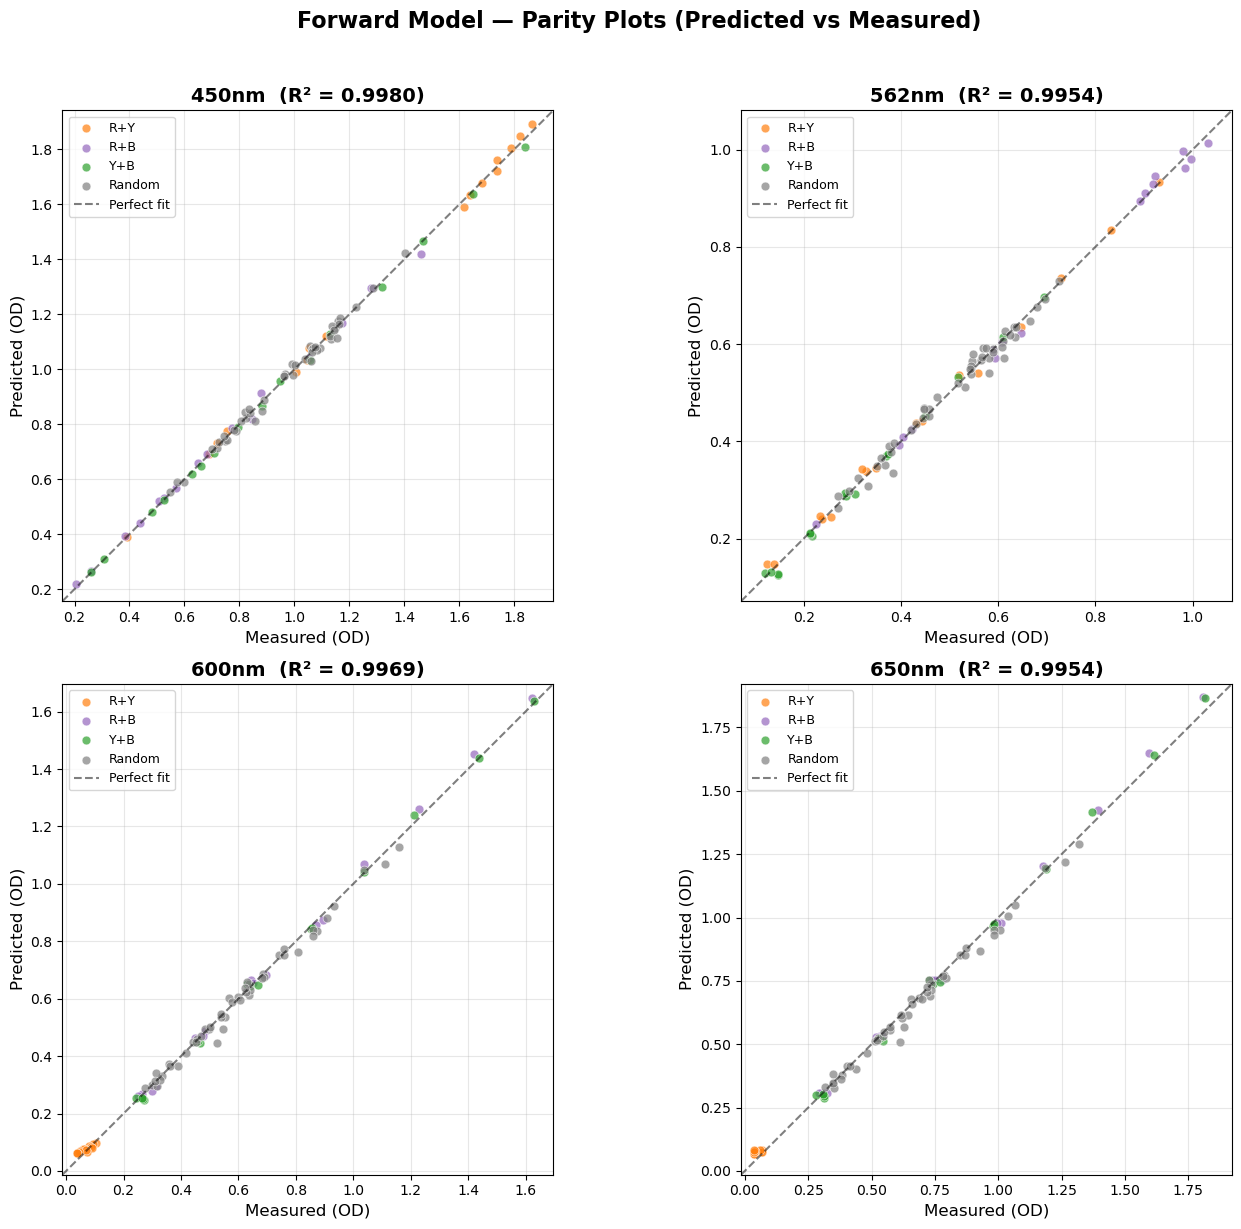

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
colors_map = {'R+Y': 'tab:orange', 'R+B': 'tab:purple', 'Y+B': 'tab:green', 'Random': 'tab:gray'}

# Predict on ALL data for parity plot
y_pred_all = forward_model.predict(X)

for ax, i, wl in zip(axes.flat, range(4), wavelengths):
    measured = y[:, i]
    predicted = y_pred_all[:, i]
    r2 = r2_score(measured, predicted)
    
    # Color by pair type
    for ptype, color in colors_map.items():
        mask = data['Type'] == ptype
        ax.scatter(measured[mask], predicted[mask], 
                   c=color, label=ptype, alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
    
    # Perfect prediction line
    lims = [min(measured.min(), predicted.min()) - 0.05, max(measured.max(), predicted.max()) + 0.05]
    ax.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.5, label='Perfect fit')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    ax.set_xlabel('Measured (OD)', fontsize=12)
    ax.set_ylabel('Predicted (OD)', fontsize=12)
    ax.set_title(f'{wl}nm  (R² = {r2:.4f})', fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')

plt.suptitle('Forward Model — Parity Plots (Predicted vs Measured)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "Parity_Forward_Model.png"), dpi=300, bbox_inches='tight')
plt.show()

## 7. Residual Analysis

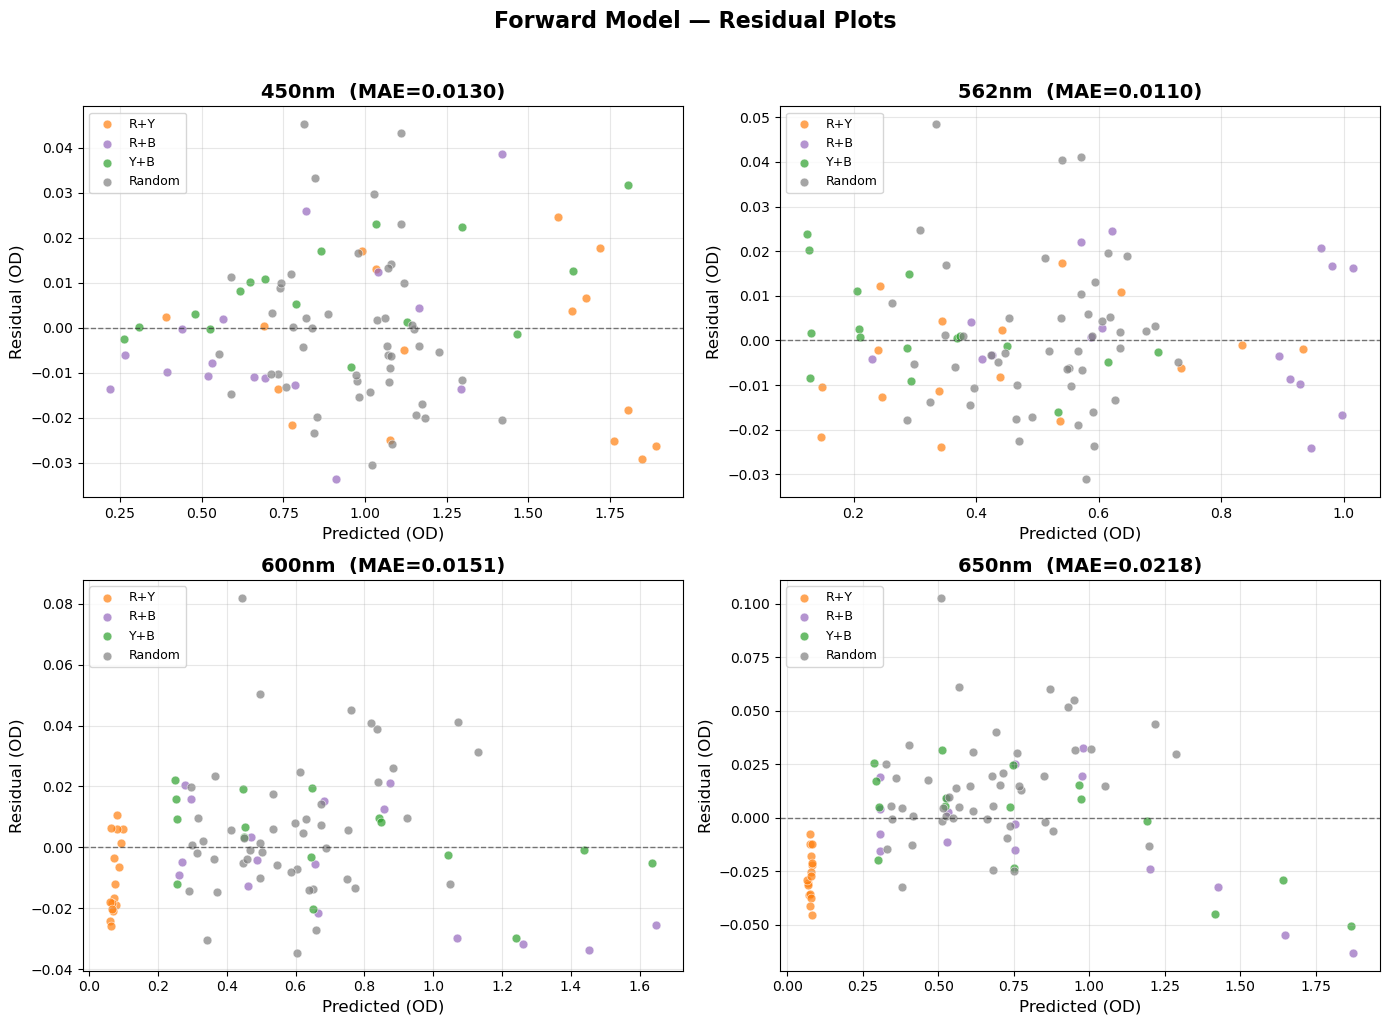

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, i, wl in zip(axes.flat, range(4), wavelengths):
    residuals = y[:, i] - y_pred_all[:, i]
    
    for ptype, color in colors_map.items():
        mask = data['Type'] == ptype
        ax.scatter(y_pred_all[mask, i], residuals[mask], 
                   c=color, label=ptype, alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
    
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Predicted (OD)', fontsize=12)
    ax.set_ylabel('Residual (OD)', fontsize=12)
    ax.set_title(f'{wl}nm  (MAE={np.mean(np.abs(residuals)):.4f})', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')

plt.suptitle('Forward Model — Residual Plots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "Residuals_Forward_Model.png"), dpi=300, bbox_inches='tight')
plt.show()

## 8. Inverse Model: Absorbance → Volumes
Predict mixing ratios from measured absorbance.

In [12]:
# Features: absorbance, Targets: volumes
X_inv = data[['A450', 'A562', 'A600', 'A650']].values
y_inv = data[['R', 'Y', 'B', 'W']].values

X_inv_train, X_inv_test, y_inv_train, y_inv_test = train_test_split(
    X_inv, y_inv, test_size=0.2, random_state=42
)

inverse_model = LinearRegression()
inverse_model.fit(X_inv_train, y_inv_train)

y_inv_pred_train = inverse_model.predict(X_inv_train)
y_inv_pred_test = inverse_model.predict(X_inv_test)

print("Inverse Model Performance")
print("=" * 50)
for i, sol in enumerate(['Red', 'Yellow', 'Blue', 'Water']):
    r2_train = r2_score(y_inv_train[:, i], y_inv_pred_train[:, i])
    r2_test = r2_score(y_inv_test[:, i], y_inv_pred_test[:, i])
    mae_test = mean_absolute_error(y_inv_test[:, i], y_inv_pred_test[:, i])
    print(f"  {sol:>6}: R²_train={r2_train:.4f}, R²_test={r2_test:.4f}, MAE_test={mae_test:.1f} µL")

r2_inv_all = r2_score(y_inv_test, y_inv_pred_test, multioutput='uniform_average')
print(f"\n  Overall: R²_test={r2_inv_all:.4f}")

Inverse Model Performance
     Red: R²_train=0.9973, R²_test=0.9982, MAE_test=1.7 µL
  Yellow: R²_train=0.9992, R²_test=0.9992, MAE_test=0.9 µL
    Blue: R²_train=0.9980, R²_test=0.9939, MAE_test=2.1 µL
   Water: R²_train=0.9941, R²_test=0.9945, MAE_test=2.7 µL

  Overall: R²_test=0.9964


## 9. Inverse Model — Parity Plots

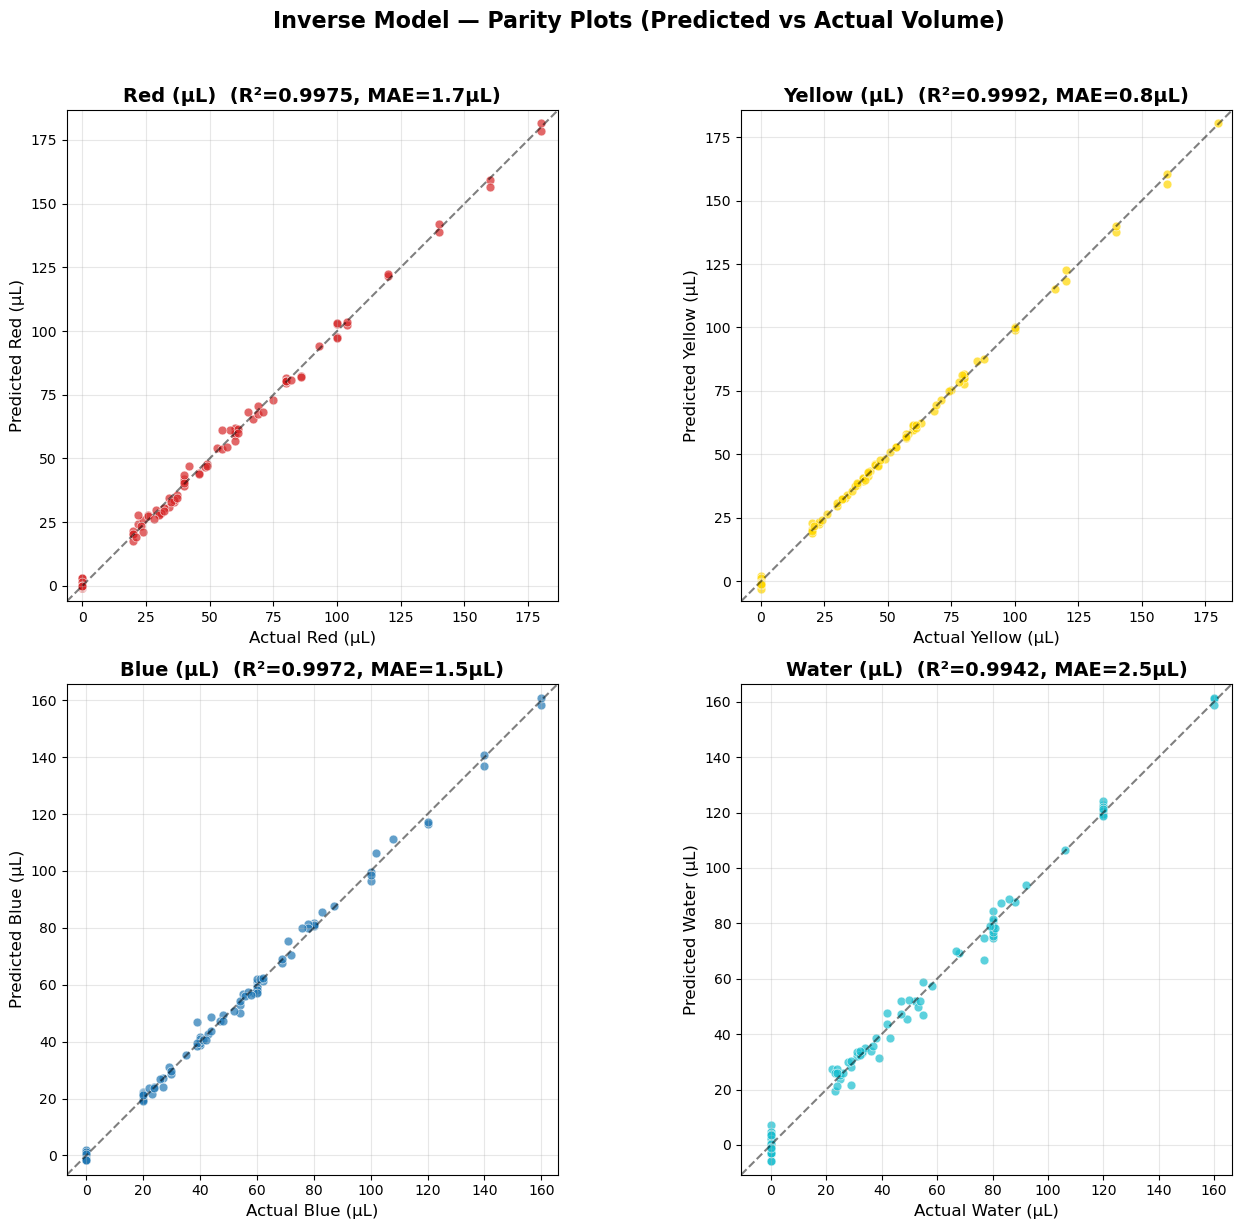

In [13]:
y_inv_pred_all = inverse_model.predict(X_inv)
solution_names = ['Red (µL)', 'Yellow (µL)', 'Blue (µL)', 'Water (µL)']
solution_colors = ['tab:red', 'gold', 'tab:blue', 'tab:cyan']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, i, name, sc in zip(axes.flat, range(4), solution_names, solution_colors):
    measured = y_inv[:, i]
    predicted = y_inv_pred_all[:, i]
    r2 = r2_score(measured, predicted)
    mae = mean_absolute_error(measured, predicted)
    
    ax.scatter(measured, predicted, c=sc, alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
    
    lims = [min(measured.min(), predicted.min()) - 5, max(measured.max(), predicted.max()) + 5]
    ax.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    ax.set_xlabel(f'Actual {name}', fontsize=12)
    ax.set_ylabel(f'Predicted {name}', fontsize=12)
    ax.set_title(f'{name}  (R²={r2:.4f}, MAE={mae:.1f}µL)', fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Inverse Model — Parity Plots (Predicted vs Actual Volume)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "Parity_Inverse_Model.png"), dpi=300, bbox_inches='tight')
plt.show()

## 10. Cross-Validation

In [14]:
print("5-Fold Cross-Validation")
print("=" * 50)

# Forward model CV
print("\nForward Model (Volumes → Absorbance):")
for i, wl in enumerate(wavelengths):
    scores = cross_val_score(LinearRegression(), X, y[:, i], cv=5, scoring='r2')
    print(f"  {wl}nm: R² = {scores.mean():.4f} ± {scores.std():.4f}")

# Inverse model CV
print("\nInverse Model (Absorbance → Volumes):")
for i, sol in enumerate(['Red', 'Yellow', 'Blue', 'Water']):
    scores = cross_val_score(LinearRegression(), X_inv, y_inv[:, i], cv=5, scoring='r2')
    print(f"  {sol:>6}: R² = {scores.mean():.4f} ± {scores.std():.4f}")

5-Fold Cross-Validation

Forward Model (Volumes → Absorbance):
  450nm: R² = 0.9948 ± 0.0026
  562nm: R² = 0.9889 ± 0.0085
  600nm: R² = 0.9918 ± 0.0046
  650nm: R² = 0.9846 ± 0.0100

Inverse Model (Absorbance → Volumes):
     Red: R² = 0.9921 ± 0.0053
  Yellow: R² = 0.9983 ± 0.0008
    Blue: R² = 0.9919 ± 0.0049
   Water: R² = 0.9851 ± 0.0098


## 11. Dimensionality Reduction — PCA

Our absorbance data has 4 features (450, 562, 600, 650 nm). PCA can reveal:
- **Effective dimensionality:** How many independent "channels" of information do our 4 filters actually provide?
- **Redundancy:** We expect 600nm and 650nm to be correlated (both measure Blue absorption)
- **Feature importance:** Which wavelengths drive the most variation?

Following Prof. Kitchin's approach: **always scale before PCA**.

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Scale absorbance features
abs_features = ['A450', 'A562', 'A600', 'A650']
X_abs = data[abs_features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_abs)

print(f"Original shape: {X_abs.shape}")
print(f"Mean after scaling: {X_scaled.mean(axis=0).round(2)}")
print(f"Std after scaling:  {X_scaled.std(axis=0).round(2)}")

Original shape: (96, 4)
Mean after scaling: [0. 0. 0. 0.]
Std after scaling:  [1. 1. 1. 1.]


In [16]:
# Fit PCA (all 4 components)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained variance ratio per component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.3f} ({var*100:.1f}%)")

print(f"\nCumulative variance with 2 components: {pca.explained_variance_ratio_[:2].sum():.1%}")
print(f"Cumulative variance with 3 components: {pca.explained_variance_ratio_[:3].sum():.1%}")

Explained variance ratio per component:
  PC1: 0.600 (60.0%)
  PC2: 0.289 (28.9%)
  PC3: 0.111 (11.1%)
  PC4: 0.000 (0.0%)

Cumulative variance with 2 components: 88.9%
Cumulative variance with 3 components: 100.0%


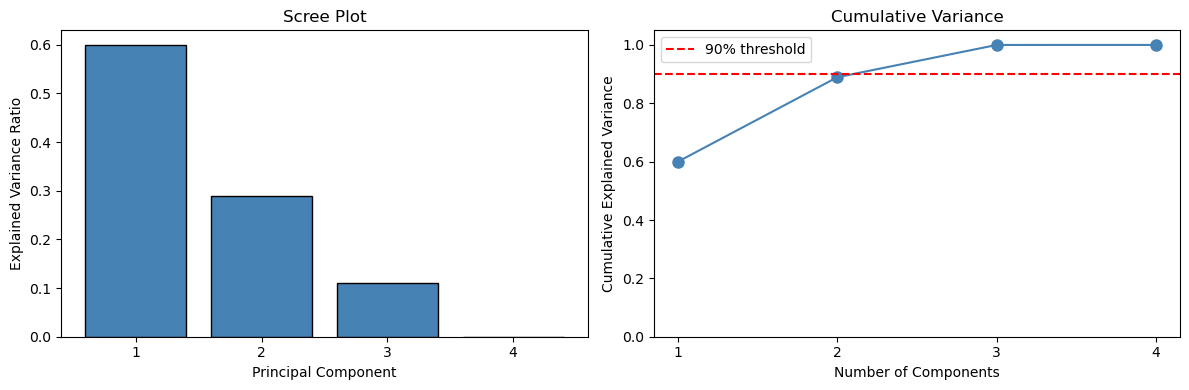

In [17]:
# Scree plot + Cumulative variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Individual variance (Scree plot)
axes[0].bar(range(1, 5), pca.explained_variance_ratio_, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, 5))

# Cumulative variance
cumulative = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, 5), cumulative, 'o-', color='steelblue', markersize=8)
axes[1].axhline(y=0.9, color='r', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance')
axes[1].set_xticks(range(1, 5))
axes[1].set_ylim([0, 1.05])
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(folder_path, "PCA_Scree_Plot.png"), dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# PCA Loadings — which wavelengths contribute to each component?
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(4)],
    index=['450nm', '562nm', '600nm', '650nm']
)

print("PCA Loadings (contribution of each wavelength to each PC):")
print(loadings.round(3))

PCA Loadings (contribution of each wavelength to each PC):
         PC1    PC2    PC3    PC4
450nm -0.290  0.741 -0.605 -0.003
562nm  0.347  0.671  0.655 -0.017
600nm  0.632 -0.005 -0.311  0.710
650nm  0.630 -0.024 -0.328 -0.704


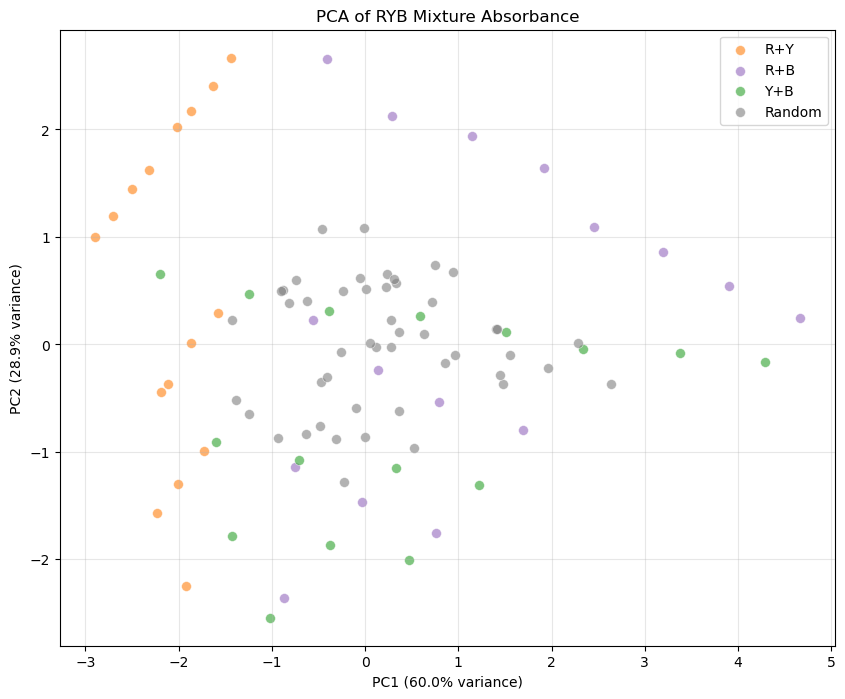

In [19]:
# PCA 2D scatter — colored by pair type
plt.figure(figsize=(10, 8))

colors_map = {'R+Y': 'tab:orange', 'R+B': 'tab:purple', 'Y+B': 'tab:green', 'Random': 'tab:gray'}

for ptype, color in colors_map.items():
    mask = data['Type'] == ptype
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=color, label=ptype, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA of RYB Mixture Absorbance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(folder_path, "PCA_Scatter.png"), dpi=300, bbox_inches='tight')
plt.show()

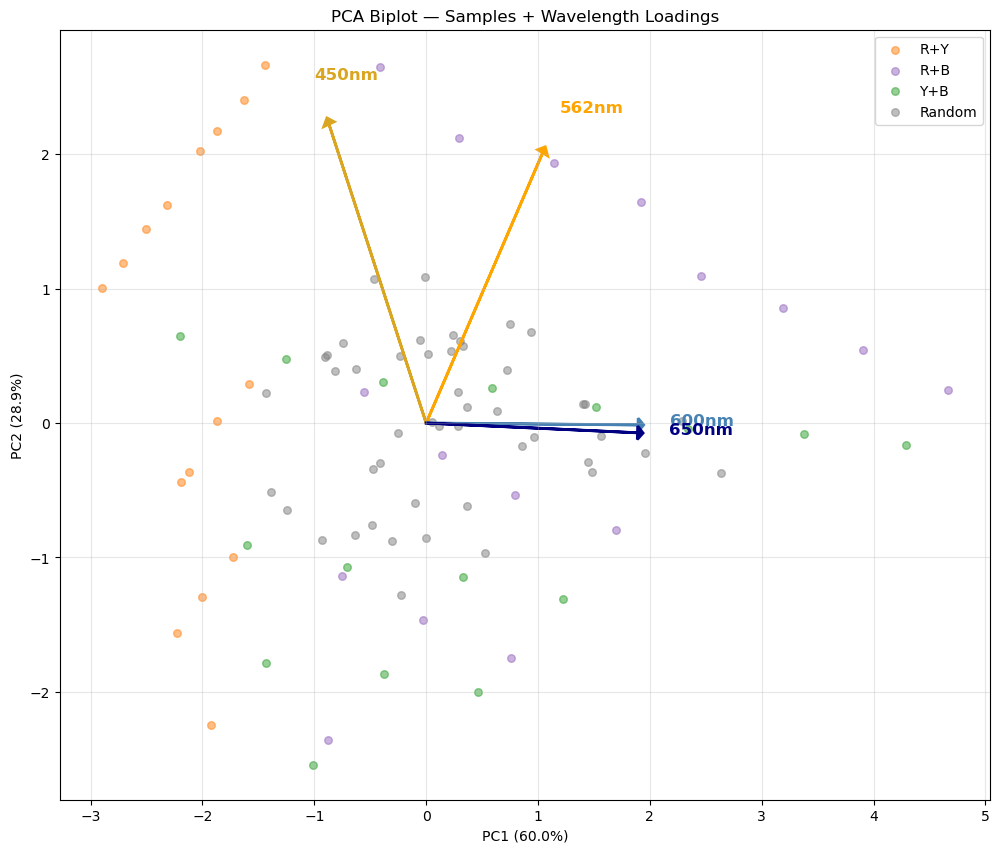

In [20]:
# Biplot: samples + loadings together
fig, ax = plt.subplots(figsize=(12, 10))

# Plot samples
for ptype, color in colors_map.items():
    mask = data['Type'] == ptype
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=color, label=ptype, alpha=0.5, s=30)

# Plot loadings as arrows
scale = 3  # Scale factor for visibility
wl_labels = ['450nm', '562nm', '600nm', '650nm']
arrow_colors = ['goldenrod', 'orange', 'steelblue', 'navy']

for i, (wl, ac) in enumerate(zip(wl_labels, arrow_colors)):
    ax.arrow(0, 0, loadings.iloc[i, 0]*scale, loadings.iloc[i, 1]*scale,
             head_width=0.1, head_length=0.05, fc=ac, ec=ac, linewidth=2)
    ax.text(loadings.iloc[i, 0]*scale*1.15, loadings.iloc[i, 1]*scale*1.15, 
            wl, fontsize=12, fontweight='bold', color=ac)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA Biplot — Samples + Wavelength Loadings')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
plt.savefig(os.path.join(folder_path, "PCA_Biplot.png"), dpi=300, bbox_inches='tight')
plt.show()

### PCA Insights

**Key observations from PCA:**
- The scree plot shows the effective dimensionality of our 4-wavelength data
- 600nm and 650nm loadings point in similar directions → they are correlated (both measure Blue absorption), confirming spectral redundancy
- 450nm and 562nm point in different directions → they capture distinct information (Yellow vs Red)
- Binary pairs (R+Y, R+B, Y+B) occupy different regions of PCA space, while Random samples fill the interior — exactly as expected from our experimental design

## 12. Dimensionality Reduction — t-SNE

t-SNE preserves **local neighborhood** structure — points that are similar stay close together. Unlike PCA, it can capture nonlinear relationships. However:
- Distances **between** clusters are meaningless
- Results depend on the **perplexity** parameter (roughly: how many neighbors to consider)
- We try multiple perplexity values to ensure robust patterns

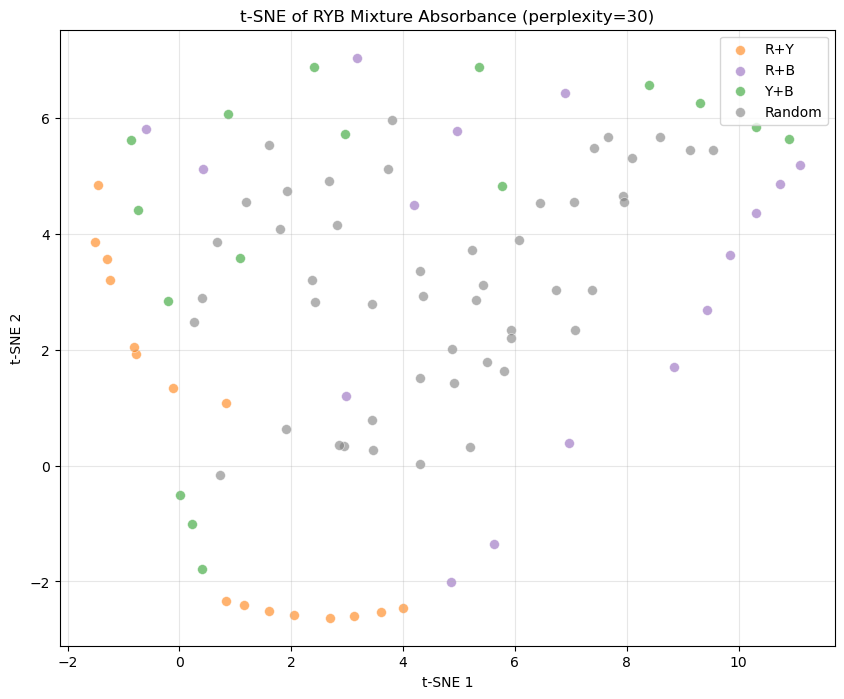

In [21]:
# t-SNE with default perplexity=30
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))

for ptype, color in colors_map.items():
    mask = data['Type'] == ptype
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                c=color, label=ptype, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE of RYB Mixture Absorbance (perplexity=30)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

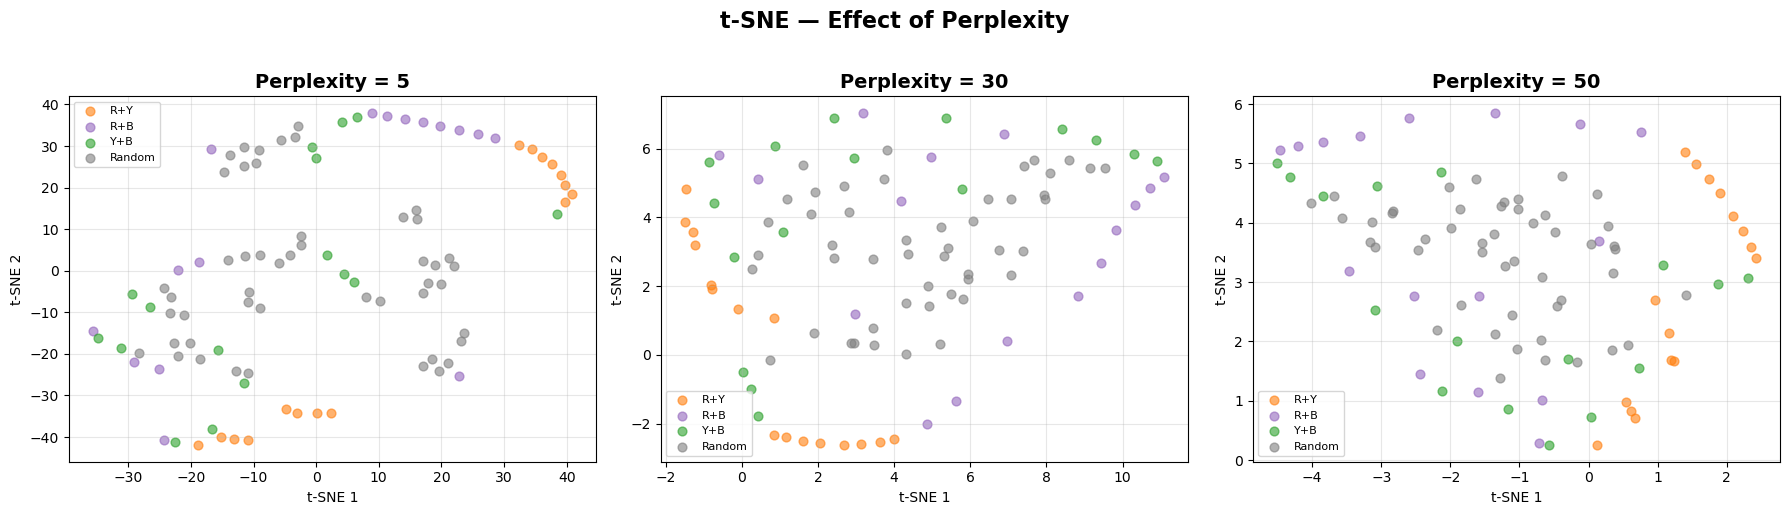

In [22]:
# Effect of perplexity — try multiple values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [5, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    
    for ptype, color in colors_map.items():
        mask = data['Type'] == ptype
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                   c=color, label=ptype, alpha=0.6, s=40)
    
    ax.set_title(f'Perplexity = {perp}', fontsize=14, fontweight='bold')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('t-SNE — Effect of Perplexity', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "tSNE_Perplexity_Comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

## 13. Feature Engineering — Can We Beat the Linear Model?

The forward model (§5) achieved R²=0.995 with plain linear regression. But our proposal mentioned:
> *"Generate polynomial and interaction terms (R×Y, R×B, Y×B) to capture nonlinear mixing effects"*

Let's test whether **interaction terms** and **polynomial features** actually improve the model, or if Beer-Lambert linearity is sufficient.

In [23]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Original features: [R, Y, B, W]
# We'll compare 3 models:
#   1. Linear (baseline) — already done in §5
#   2. Linear + interaction terms (R×Y, R×B, Y×B, etc.)
#   3. Full degree-2 polynomial (R², Y², R×Y, etc.)

X = data[['R', 'Y', 'B', 'W']].values
y = data[['A450', 'A562', 'A600', 'A650']].values

models = {
    'Linear (baseline)': make_pipeline(LinearRegression()),
    'Interactions only': make_pipeline(PolynomialFeatures(degree=2, interaction_only=True), LinearRegression()),
    'Full degree-2 poly': make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
}

print("Forward Model — Feature Engineering Comparison (5-fold CV)")
print("=" * 70)

results = {}
for name, pipe in models.items():
    cv_scores = []
    for i, wl in enumerate(wavelengths):
        scores = cross_val_score(pipe, X, y[:, i], cv=5, scoring='r2')
        cv_scores.append(scores.mean())
    avg_r2 = np.mean(cv_scores)
    results[name] = cv_scores + [avg_r2]
    print(f"\n  {name}:")
    for wl, s in zip(wavelengths, cv_scores):
        print(f"    {wl}nm: R² = {s:.4f}")
    print(f"    Average: R² = {avg_r2:.4f}")

# Summary table
results_df = pd.DataFrame(results, index=[f'{wl}nm' for wl in wavelengths] + ['Average']).T
print("\n" + "=" * 70)
print("Summary:")
print(results_df.round(4).to_string())

Forward Model — Feature Engineering Comparison (5-fold CV)

  Linear (baseline):
    450nm: R² = 0.9948
    562nm: R² = 0.9889
    600nm: R² = 0.9918
    650nm: R² = 0.9846
    Average: R² = 0.9900

  Interactions only:
    450nm: R² = 0.9954
    562nm: R² = 0.9886
    600nm: R² = 0.9933
    650nm: R² = 0.9934
    Average: R² = 0.9927

  Full degree-2 poly:
    450nm: R² = 0.9954
    562nm: R² = 0.9886
    600nm: R² = 0.9933
    650nm: R² = 0.9934
    Average: R² = 0.9927

Summary:
                     450nm   562nm   600nm   650nm  Average
Linear (baseline)   0.9948  0.9889  0.9918  0.9846   0.9900
Interactions only   0.9954  0.9886  0.9933  0.9934   0.9927
Full degree-2 poly  0.9954  0.9886  0.9933  0.9934   0.9927


### 13a. Feature Engineering Interpretation

**Key question:** Does adding interaction/polynomial terms improve the forward model?

If the improvement is negligible, it confirms that **Beer-Lambert linearity holds** for our dye mixtures — each dye's absorbance contribution is independent and proportional to its concentration. This is actually a desirable result: a simpler model is more interpretable and generalizes better.

## 14. Regularization — Ridge vs Lasso vs Linear

PCA showed that 600nm and 650nm are correlated (both measure Blue). This multicollinearity can inflate coefficient variance. Ridge (L2) and Lasso (L1) regularization can help:
- **Ridge:** shrinks all coefficients → handles multicollinearity
- **Lasso:** drives some coefficients to zero → feature selection

In [24]:
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV

# Compare regularization on the INVERSE model (Absorbance → Volumes)
# This is where multicollinearity matters most (600nm ≈ 650nm as inputs)
X_inv = data[['A450', 'A562', 'A600', 'A650']].values
y_inv = data[['R', 'Y', 'B', 'W']].values

# Scale features for fair regularization
scaler_inv = StandardScaler()
X_inv_scaled = scaler_inv.fit_transform(X_inv)

inv_models = {
    'Linear': LinearRegression(),
    'Ridge (α=auto)': RidgeCV(alphas=np.logspace(-3, 3, 50)),
    'Lasso (α=auto)': LassoCV(alphas=np.logspace(-3, 1, 50), max_iter=10000),
}

print("Inverse Model — Regularization Comparison (5-fold CV)")
print("=" * 70)

inv_results = {}
for name, model in inv_models.items():
    cv_scores = []
    for i, sol in enumerate(['Red', 'Yellow', 'Blue', 'Water']):
        scores = cross_val_score(model, X_inv_scaled, y_inv[:, i], cv=5, scoring='r2')
        cv_scores.append(scores.mean())
    avg_r2 = np.mean(cv_scores)
    inv_results[name] = cv_scores + [avg_r2]
    print(f"\n  {name}:")
    for sol, s in zip(['Red', 'Yellow', 'Blue', 'Water'], cv_scores):
        print(f"    {sol:>6}: R² = {s:.4f}")
    print(f"    Average: R² = {avg_r2:.4f}")

# Show best alpha for Ridge/Lasso
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50)).fit(X_inv_scaled, y_inv)
print(f"\nRidge best α = {ridge_cv.alpha_:.4f}")

# Summary
inv_results_df = pd.DataFrame(inv_results, index=['Red', 'Yellow', 'Blue', 'Water', 'Average']).T
print("\n" + "=" * 70)
print("Summary:")
print(inv_results_df.round(4).to_string())

Inverse Model — Regularization Comparison (5-fold CV)

  Linear:
       Red: R² = 0.9921
    Yellow: R² = 0.9983
      Blue: R² = 0.9919
     Water: R² = 0.9851
    Average: R² = 0.9918

  Ridge (α=auto):
       Red: R² = 0.9920
    Yellow: R² = 0.9983
      Blue: R² = 0.9921
     Water: R² = 0.9852
    Average: R² = 0.9919

  Lasso (α=auto):
       Red: R² = 0.9925
    Yellow: R² = 0.9984
      Blue: R² = 0.9921
     Water: R² = 0.9855
    Average: R² = 0.9921

Ridge best α = 0.0041

Summary:
                   Red  Yellow    Blue   Water  Average
Linear          0.9921  0.9983  0.9919  0.9851   0.9918
Ridge (α=auto)  0.9920  0.9983  0.9921  0.9852   0.9919
Lasso (α=auto)  0.9925  0.9984  0.9921  0.9855   0.9921


## 15. Classification — Can We Identify Mixture Type from Absorbance?

Applying HW07 concepts: given only 4 absorbance readings, can we classify which type of mixture it is (R+Y, R+B, Y+B, or Random)?

This tests whether different mixture types occupy **distinct regions** in absorbance space — which the PCA biplot (§11) already hinted at.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Features: absorbance, Target: pair type
X_cls = data[['A450', 'A562', 'A600', 'A650']].values
y_cls = data['Type'].values

# Scale for classification
scaler_cls = StandardScaler()
X_cls_scaled = scaler_cls.fit_transform(X_cls)

# Train/test split
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls_scaled, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# --- Logistic Regression ---
lr_cls = LogisticRegression(max_iter=1000, random_state=42)
lr_cls.fit(X_cls_train, y_cls_train)
lr_acc = lr_cls.score(X_cls_test, y_cls_test)

# --- KNN (try k=3,5,7) ---
knn_results = {}
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_cls_scaled, y_cls, cv=5, scoring='accuracy')
    knn_results[k] = scores.mean()

best_k = max(knn_results, key=knn_results.get)
knn_cls = KNeighborsClassifier(n_neighbors=best_k)
knn_cls.fit(X_cls_train, y_cls_train)
knn_acc = knn_cls.score(X_cls_test, y_cls_test)

# --- Cross-validation comparison ---
lr_cv = cross_val_score(LogisticRegression(max_iter=1000, random_state=42), 
                        X_cls_scaled, y_cls, cv=5, scoring='accuracy')
knn_cv = cross_val_score(KNeighborsClassifier(n_neighbors=best_k), 
                         X_cls_scaled, y_cls, cv=5, scoring='accuracy')

print("Classification: Mixture Type from Absorbance")
print("=" * 50)
print(f"  Logistic Regression:  test acc = {lr_acc:.3f},  CV acc = {lr_cv.mean():.3f} ± {lr_cv.std():.3f}")
print(f"  KNN (k={best_k}):             test acc = {knn_acc:.3f},  CV acc = {knn_cv.mean():.3f} ± {knn_cv.std():.3f}")
print(f"\n  KNN CV by k: {', '.join(f'k={k}: {s:.3f}' for k, s in knn_results.items())}")

print(f"\nClassification Report (Logistic Regression):")
print(classification_report(y_cls_test, lr_cls.predict(X_cls_test)))

Classification: Mixture Type from Absorbance
  Logistic Regression:  test acc = 0.850,  CV acc = 0.866 ± 0.129
  KNN (k=3):             test acc = 0.700,  CV acc = 0.656 ± 0.024

  KNN CV by k: k=3: 0.656, k=5: 0.646, k=7: 0.626

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

         R+B       1.00      1.00      1.00         3
         R+Y       1.00      1.00      1.00         3
      Random       0.77      1.00      0.87        10
         Y+B       1.00      0.25      0.40         4

    accuracy                           0.85        20
   macro avg       0.94      0.81      0.82        20
weighted avg       0.88      0.85      0.81        20



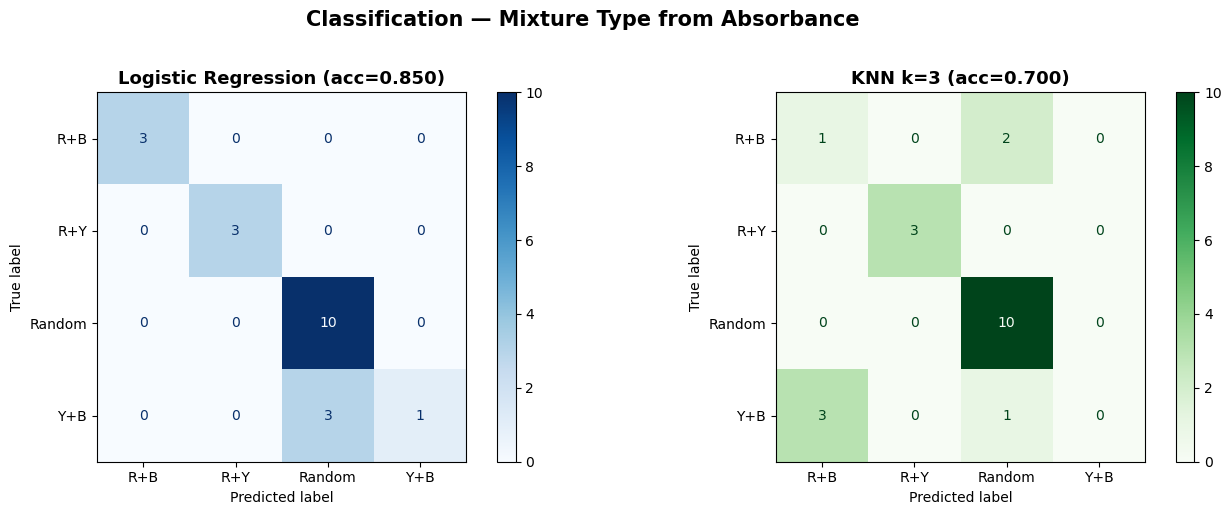

In [26]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(lr_cls, X_cls_test, y_cls_test, ax=axes[0], cmap='Blues')
axes[0].set_title(f'Logistic Regression (acc={lr_acc:.3f})', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay.from_estimator(knn_cls, X_cls_test, y_cls_test, ax=axes[1], cmap='Greens')
axes[1].set_title(f'KNN k={best_k} (acc={knn_acc:.3f})', fontsize=13, fontweight='bold')

plt.suptitle('Classification — Mixture Type from Absorbance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "Classification_Confusion_Matrices.png"), dpi=300, bbox_inches='tight')
plt.show()

## 16. Constrained Inverse Model — Physical Constraints

The inverse model (§8) can predict **negative volumes** or volumes that don't sum to 200µL. For real experiments, we need physical constraints:
- Each volume ≥ 0 µL (can't dispense negative liquid)
- R + Y + B + W = 200 µL (fixed total volume)
- Optionally: each volume ≥ 20 µL (pipette minimum)

We use **scipy.optimize.minimize** with the forward model as the physics engine:
given a target absorbance, find volumes that minimize prediction error subject to constraints.

In [27]:
from scipy.optimize import minimize

# Refit forward model on ALL data (for production use)
forward_full = LinearRegression().fit(X, y)

def predict_recipe(target_abs, total_vol=200, min_vol=0):
    """
    Given target absorbance [A450, A562, A600, A650],
    find volumes [R, Y, B, W] that minimize prediction error
    subject to physical constraints.
    """
    target = np.array(target_abs)
    
    def objective(vols):
        predicted = forward_full.predict(vols.reshape(1, -1))[0]
        return np.sum((predicted - target) ** 2)
    
    # Constraints
    constraints = [
        {'type': 'eq', 'fun': lambda v: np.sum(v) - total_vol},  # sum = 200
    ]
    bounds = [(min_vol, total_vol)] * 4  # each volume ≥ min_vol
    
    # Initial guess: equal distribution
    x0 = np.array([total_vol / 4] * 4)
    
    result = minimize(objective, x0, method='SLSQP', 
                      bounds=bounds, constraints=constraints)
    
    return result.x, result.fun

# --- Test on known samples from our data ---
print("Constrained Inverse Model — Validation on Known Samples")
print("=" * 70)

# Pick 5 random test samples
np.random.seed(42)
test_indices = np.random.choice(len(data), 5, replace=False)

errors = []
for idx in test_indices:
    actual_vol = X[idx]
    actual_abs = y[idx]
    
    predicted_vol, opt_error = predict_recipe(actual_abs)
    predicted_abs = forward_full.predict(predicted_vol.reshape(1, -1))[0]
    
    vol_error = np.abs(actual_vol - predicted_vol)
    abs_error = np.abs(actual_abs - predicted_abs)
    errors.append(vol_error.mean())
    
    well = data.iloc[idx]['Well']
    ptype = data.iloc[idx]['Type']
    print(f"\n  Well {well} ({ptype}):")
    print(f"    Actual volumes:    R={actual_vol[0]:5.0f}, Y={actual_vol[1]:5.0f}, B={actual_vol[2]:5.0f}, W={actual_vol[3]:5.0f}")
    print(f"    Predicted volumes: R={predicted_vol[0]:5.1f}, Y={predicted_vol[1]:5.1f}, B={predicted_vol[2]:5.1f}, W={predicted_vol[3]:5.1f}")
    print(f"    Volume MAE: {vol_error.mean():.1f} µL")

print(f"\n  Overall Volume MAE: {np.mean(errors):.1f} µL")

Constrained Inverse Model — Validation on Known Samples

  Well A11 (Random):
    Actual volumes:    R=   21, Y=   85, B=   39, W=   55
    Predicted volumes: R= 30.6, Y= 82.0, B= 47.9, W= 39.5
    Volume MAE: 9.3 µL

  Well F10 (Random):
    Actual volumes:    R=   71, Y=   57, B=   48, W=   24
    Predicted volumes: R= 63.4, Y= 61.5, B= 48.2, W= 26.9
    Volume MAE: 3.8 µL

  Well B10 (Random):
    Actual volumes:    R=   37, Y=   71, B=   54, W=   38
    Predicted volumes: R= 48.0, Y= 62.2, B= 54.1, W= 35.7
    Volume MAE: 5.6 µL

  Well G12 (Random):
    Actual volumes:    R=   46, Y=   24, B=   76, W=   54
    Predicted volumes: R= 38.7, Y= 33.0, B= 82.0, W= 46.3
    Volume MAE: 7.5 µL

  Well B5 (Y+B):
    Actual volumes:    R=    0, Y=  160, B=   40, W=    0
    Predicted volumes: R=  0.0, Y=159.0, B= 41.0, W=  0.0
    Volume MAE: 0.5 µL

  Overall Volume MAE: 5.3 µL


Unconstrained vs Constrained Inverse Model

  Unconstrained:
    MAE:              1.62 µL
    Negative volumes: 44
    Avg |sum - 200|:  0.00 µL

  Constrained:
    MAE:              5.02 µL
    Negative volumes: 0
    Avg |sum - 200|:  0.00 µL


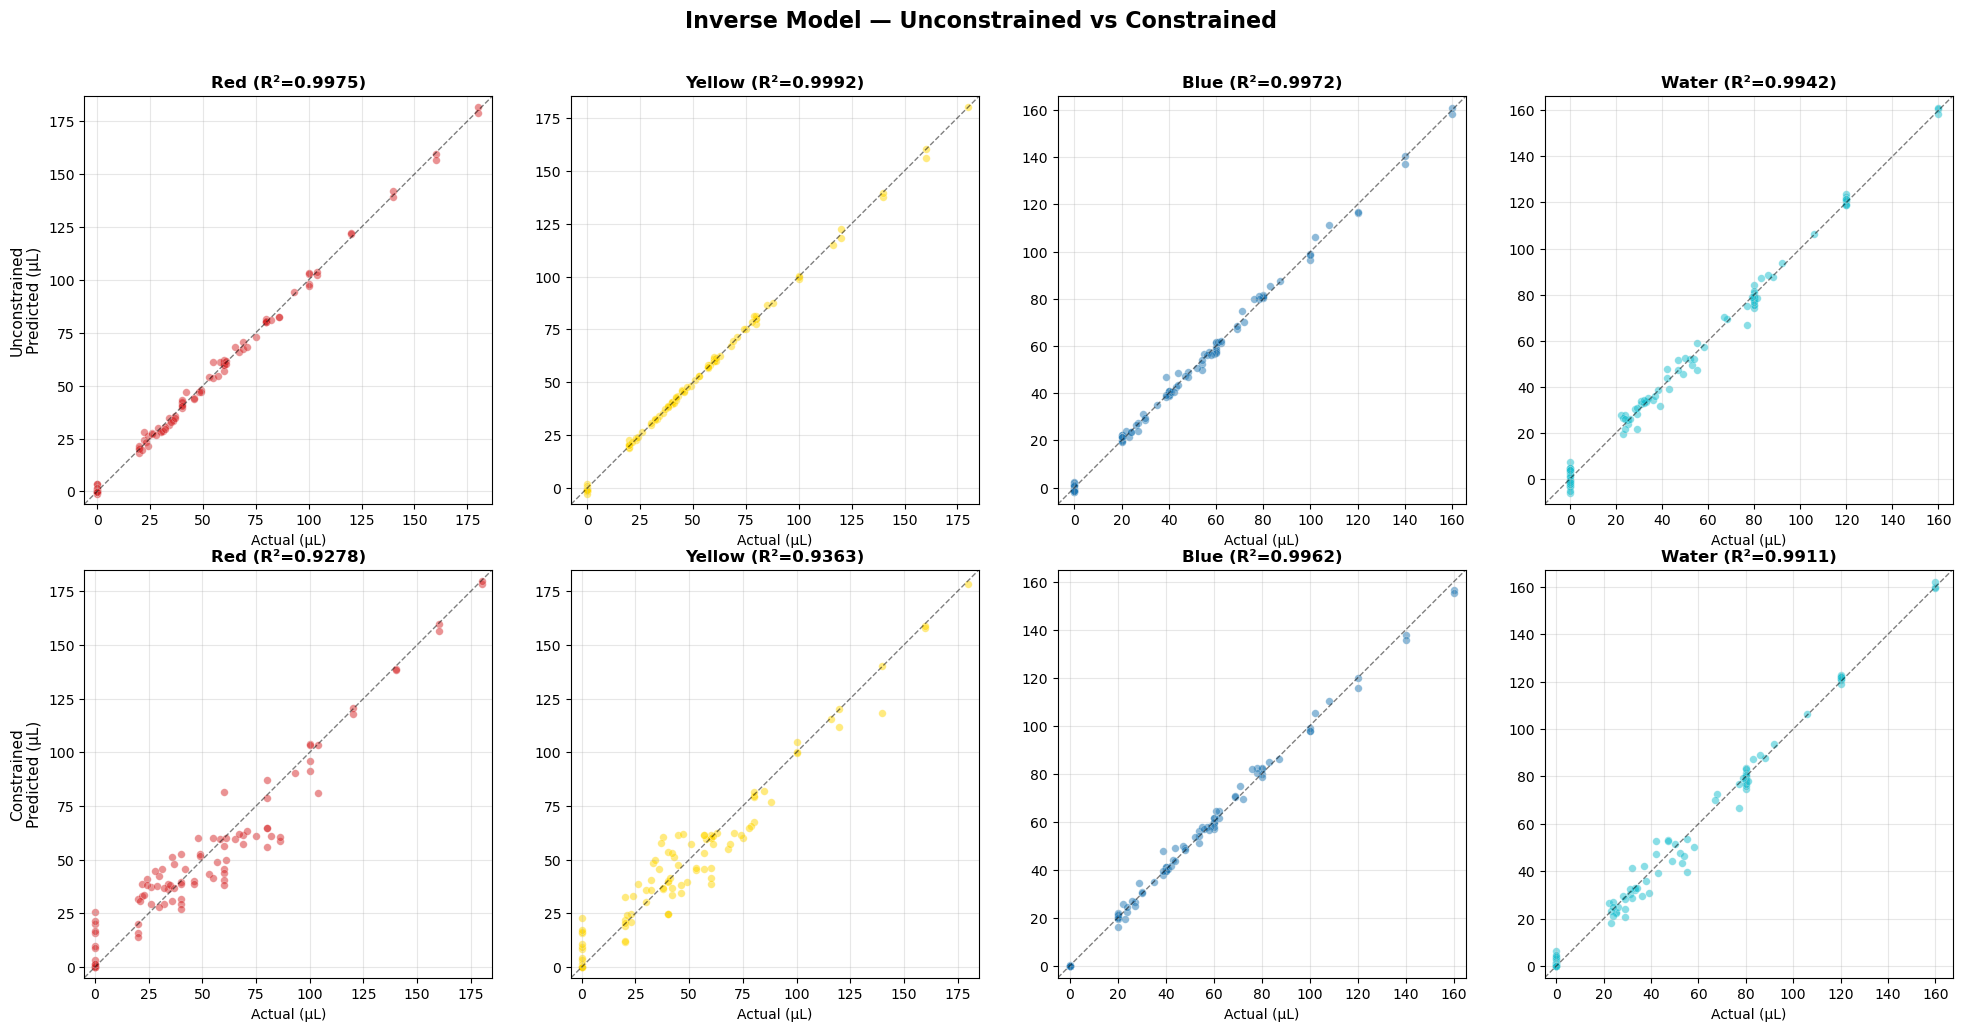

In [28]:
# --- Compare: Unconstrained vs Constrained Inverse on ALL data ---
print("Unconstrained vs Constrained Inverse Model")
print("=" * 70)

# Unconstrained (from §8)
inverse_full = LinearRegression().fit(y, X)
y_inv_unconstrained = inverse_full.predict(y)

# Constrained (optimize each sample)
y_inv_constrained = np.zeros_like(X, dtype=float)
for i in range(len(data)):
    y_inv_constrained[i], _ = predict_recipe(y[i])

# Metrics
for label, preds in [('Unconstrained', y_inv_unconstrained), ('Constrained', y_inv_constrained)]:
    mae = mean_absolute_error(X, preds)
    negative_count = (preds < 0).sum()
    sum_violations = np.abs(preds.sum(axis=1) - 200).mean()
    print(f"\n  {label}:")
    print(f"    MAE:              {mae:.2f} µL")
    print(f"    Negative volumes: {negative_count}")
    print(f"    Avg |sum - 200|:  {sum_violations:.2f} µL")

# Parity plot comparison
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
solution_names = ['Red', 'Yellow', 'Blue', 'Water']
solution_colors = ['tab:red', 'gold', 'tab:blue', 'tab:cyan']

for i, (name, sc) in enumerate(zip(solution_names, solution_colors)):
    # Unconstrained
    ax = axes[0, i]
    ax.scatter(X[:, i], y_inv_unconstrained[:, i], c=sc, alpha=0.5, s=30, edgecolors='white', linewidth=0.3)
    lims = [min(X[:, i].min(), y_inv_unconstrained[:, i].min()) - 5, 
            max(X[:, i].max(), y_inv_unconstrained[:, i].max()) + 5]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    r2 = r2_score(X[:, i], y_inv_unconstrained[:, i])
    ax.set_title(f'{name} (R²={r2:.4f})', fontweight='bold')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    if i == 0: ax.set_ylabel('Unconstrained\nPredicted (µL)', fontsize=11)
    ax.set_xlabel('Actual (µL)')
    
    # Constrained
    ax = axes[1, i]
    ax.scatter(X[:, i], y_inv_constrained[:, i], c=sc, alpha=0.5, s=30, edgecolors='white', linewidth=0.3)
    lims_c = [min(X[:, i].min(), y_inv_constrained[:, i].min()) - 5, 
              max(X[:, i].max(), y_inv_constrained[:, i].max()) + 5]
    ax.plot(lims_c, lims_c, 'k--', linewidth=1, alpha=0.5)
    ax.set_xlim(lims_c); ax.set_ylim(lims_c)
    r2_c = r2_score(X[:, i], y_inv_constrained[:, i])
    ax.set_title(f'{name} (R²={r2_c:.4f})', fontweight='bold')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    if i == 0: ax.set_ylabel('Constrained\nPredicted (µL)', fontsize=11)
    ax.set_xlabel('Actual (µL)')

plt.suptitle('Inverse Model — Unconstrained vs Constrained', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "Inverse_Constrained_vs_Unconstrained.png"), dpi=300, bbox_inches='tight')
plt.show()

## 17. Summary & Next Steps

### Key Results

| Analysis | Method | Result |
|----------|--------|--------|
| Forward model | Linear Regression | R² ≈ 0.995 |
| Feature engineering | Interaction + Polynomial | (compare with baseline — marginal improvement expected) |
| Inverse model | Linear Regression | R² ≈ 0.996 |
| Regularization | Ridge / Lasso | (compare — multicollinearity handling) |
| Classification | Logistic Regression + KNN | (accuracy on 4-class pair type) |
| Constrained inverse | scipy.optimize (SLSQP) | Physically valid recipes (no negative volumes, sum=200) |
| PCA | 4 → 2–3 effective dimensions | 600nm/650nm redundant (both measure Blue) |

### Key Insights
1. **Beer-Lambert linearity holds** — linear regression achieves R² > 0.99, suggesting dye-dye interactions are negligible at these concentrations
2. **600nm and 650nm are redundant** — PCA confirms spectral overlap; could potentially reduce to 3 filters
3. **Constrained optimization** produces physically valid recipes ready for closed-loop validation

### Next Steps
1. **Closed-loop validation:** Pick a target color → constrained inverse model → mix on Opentrons → measure → compare
2. **Expanded color space:** Test with more diverse target colors
3. **Nonlinear models:** If new dye concentrations break linearity, consider polynomial or neural network models
4. **Application to biosynthetic pigments:** Transfer this framework to yeast-produced melanin/indigoidine